# 08 - Model Evaluation

## Electricity Consumption Forecasting

### Objective

Perform a detailed evaluation of the best forecasting model selected in Notebook 07.

The current best model is expected to be **HistGradientBoosting**, but this notebook determines the best model directly from the saved model comparison results.

We will evaluate:

- MAE, RMSE and R²
- Improvement over the previous-hour baseline
- Actual vs predicted consumption
- Residuals
- Error by hour
- Error by day of week
- Error by month
- Peak-consumption prediction
- Prediction examples


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

## 2. Load Test Data and Model Results


In [2]:
test_path = "../data/processed/test_dataset.csv"
results_path = "../data/processed/model_comparison_results.csv"
model_path = "../models/best_electricity_forecasting_model.joblib"

test_df = pd.read_csv(
    test_path,
    parse_dates=["DateTime"]
).set_index("DateTime").sort_index()

results_df = pd.read_csv(results_path)

print("Test dataset shape:", test_df.shape)
print("\nTest period:")
print(test_df.index.min(), "to", test_df.index.max())

print("\nModel comparison:")
display(results_df)


Test dataset shape: (4883, 12)

Test period:
2009-03-16 13:00:00 to 2009-10-05 23:00:00

Model comparison:


,Model,MAE,RMSE,R2
0,HistGradientBoosting,0.374329,0.518418,0.455438
1,Random Forest,0.387896,0.533059,0.424245
2,Linear Regression,0.466991,0.618019,0.226089
3,Previous-Hour Baseline,0.534101,0.795210,-0.281300


## 3. Identify and Load the Best Model


In [3]:
ml_results = results_df[
    results_df["Model"] != "Previous-Hour Baseline"
].sort_values("MAE")

best_model_name = ml_results.iloc[0]["Model"]

best_model = joblib.load(model_path)

print("Best model:", best_model_name)
print("Loaded model:", type(best_model).__name__)


Best model: HistGradientBoosting
Loaded model: HistGradientBoostingRegressor


## 4. Prepare Test Features and Target


In [4]:
feature_columns = [
    "Hour",
    "DayOfWeek",
    "Month",
    "Quarter",
    "IsWeekend",
    "Lag_1h",
    "Lag_24h",
    "Lag_168h",
    "Rolling_24h",
    "Rolling_168h"
]

target_column = "Target_Next_Hour"

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_test shape: (4883, 10)
y_test shape: (4883,)


## 5. Generate Predictions


In [5]:
best_predictions = best_model.predict(X_test)

baseline_predictions = X_test["Lag_1h"].values

print("Predictions generated:", len(best_predictions))


Predictions generated: 4883


## 6. Calculate Final Model Metrics


In [6]:
best_mae = mean_absolute_error(y_test, best_predictions)
best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))
best_r2 = r2_score(y_test, best_predictions)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("===== FINAL MODEL METRICS =====")
print("Model:", best_model_name)
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R²  :", best_r2)

print("\n===== BASELINE METRICS =====")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)


===== FINAL MODEL METRICS =====
Model: HistGradientBoosting
MAE : 0.374329406315359
RMSE: 0.5184178276691596
R²  : 0.45543829902335753

===== BASELINE METRICS =====
MAE : 0.534100681393319
RMSE: 0.7952098232328327
R²  : -0.2812996599045363


## 7. Calculate Improvement Over Baseline

This shows how much the selected ML model improves over simply using the previous hour's consumption.

For MAE and RMSE, a positive percentage means the ML model reduced the error.


In [7]:
mae_improvement = (baseline_mae - best_mae) / baseline_mae * 100
rmse_improvement = (baseline_rmse - best_rmse) / baseline_rmse * 100

print("MAE improvement over baseline :", mae_improvement, "%")
print("RMSE improvement over baseline:", rmse_improvement, "%")


MAE improvement over baseline : 29.914074376606585 %
RMSE improvement over baseline: 34.80741654302101 %


## 8. Create Prediction DataFrame

A separate prediction table makes later analysis easier and provides a useful output for reports or dashboards.


In [8]:
evaluation_df = pd.DataFrame(
    {
        "Actual": y_test.values,
        "Predicted": best_predictions,
        "Baseline": baseline_predictions
    },
    index=y_test.index
)

evaluation_df["Error"] = (
    evaluation_df["Actual"] - evaluation_df["Predicted"]
)

evaluation_df["Absolute_Error"] = (
    evaluation_df["Error"].abs()
)

evaluation_df["Hour"] = evaluation_df.index.hour
evaluation_df["DayOfWeek"] = evaluation_df.index.dayofweek
evaluation_df["Month"] = evaluation_df.index.month
evaluation_df["DayName"] = evaluation_df.index.day_name()

evaluation_df.head()


,Actual,Predicted,Baseline,Error,Absolute_Error,Hour,DayOfWeek,Month,DayName
DateTime,,,,,,,,,
2009-03-16 13:00:00,0.266300,1.015103,1.351733,-0.748803,0.748803,13,0,3,Monday
2009-03-16 14:00:00,0.277667,1.161157,1.019467,-0.883490,0.883490,14,0,3,Monday
2009-03-16 15:00:00,0.315533,0.495002,0.266300,-0.179468,0.179468,15,0,3,Monday
2009-03-16 16:00:00,0.297867,0.555103,0.277667,-0.257237,0.257237,16,0,3,Monday
2009-03-16 17:00:00,0.318733,1.091982,0.315533,-0.773248,0.773248,17,0,3,Monday


## 9. Actual vs Predicted Consumption

We plot the first 1,000 test observations so that the chart remains readable.

A good model should generally follow the major peaks and drops in actual consumption.


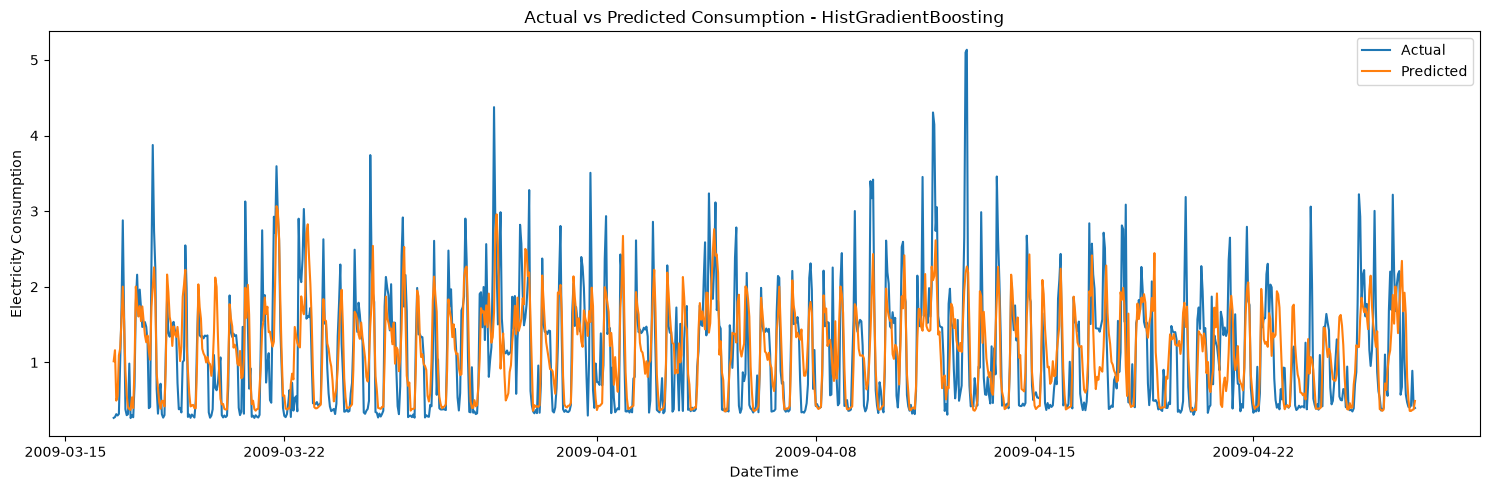

In [9]:
plot_points = min(1000, len(evaluation_df))

plt.figure(figsize=(15, 5))

plt.plot(
    evaluation_df.index[:plot_points],
    evaluation_df["Actual"].iloc[:plot_points],
    label="Actual"
)

plt.plot(
    evaluation_df.index[:plot_points],
    evaluation_df["Predicted"].iloc[:plot_points],
    label="Predicted"
)

plt.title(f"Actual vs Predicted Consumption - {best_model_name}")
plt.xlabel("DateTime")
plt.ylabel("Electricity Consumption")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Actual vs Predicted Scatter Plot

Points close to the diagonal relationship indicate more accurate predictions.


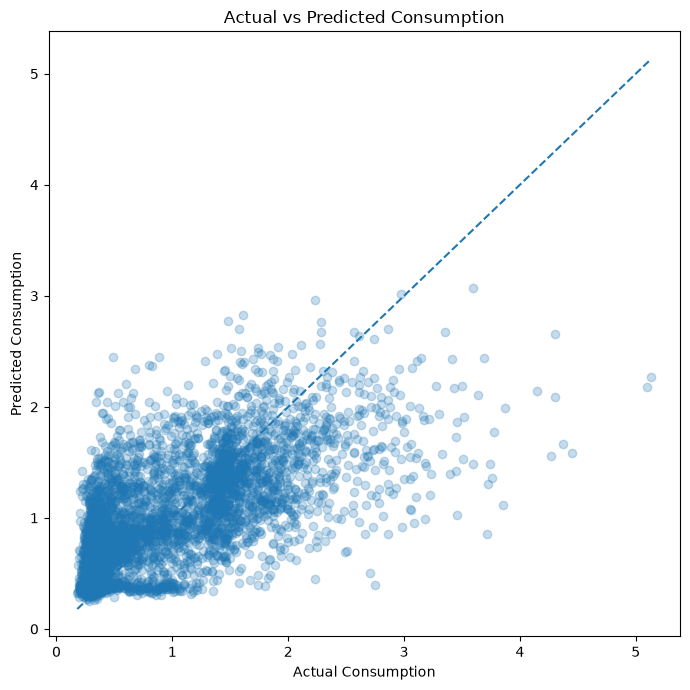

In [10]:
plt.figure(figsize=(7, 7))

plt.scatter(
    evaluation_df["Actual"],
    evaluation_df["Predicted"],
    alpha=0.25
)

minimum = min(
    evaluation_df["Actual"].min(),
    evaluation_df["Predicted"].min()
)

maximum = max(
    evaluation_df["Actual"].max(),
    evaluation_df["Predicted"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Actual vs Predicted Consumption")
plt.xlabel("Actual Consumption")
plt.ylabel("Predicted Consumption")
plt.tight_layout()
plt.show()


## 11. Residual Distribution

Residual = Actual − Predicted.

A residual close to zero indicates a small prediction error.


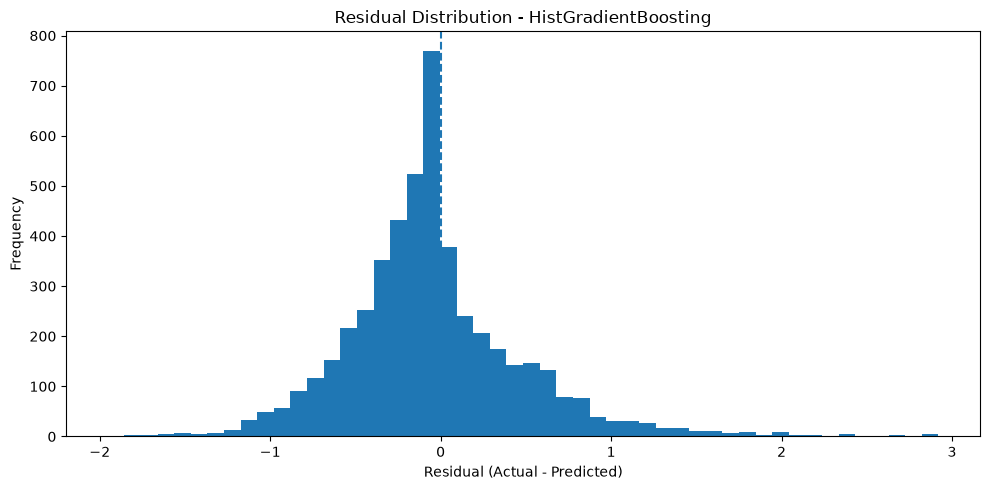

Mean residual: -0.046516790082531984
Median residual: -0.08324368654370451


In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    evaluation_df["Error"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(f"Residual Distribution - {best_model_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Mean residual:", evaluation_df["Error"].mean())
print("Median residual:", evaluation_df["Error"].median())


## 12. Error by Hour of Day

This analysis answers:

**At which hours does the model make larger or smaller errors?**

This is especially useful for electricity consumption because consumption has strong hourly patterns.


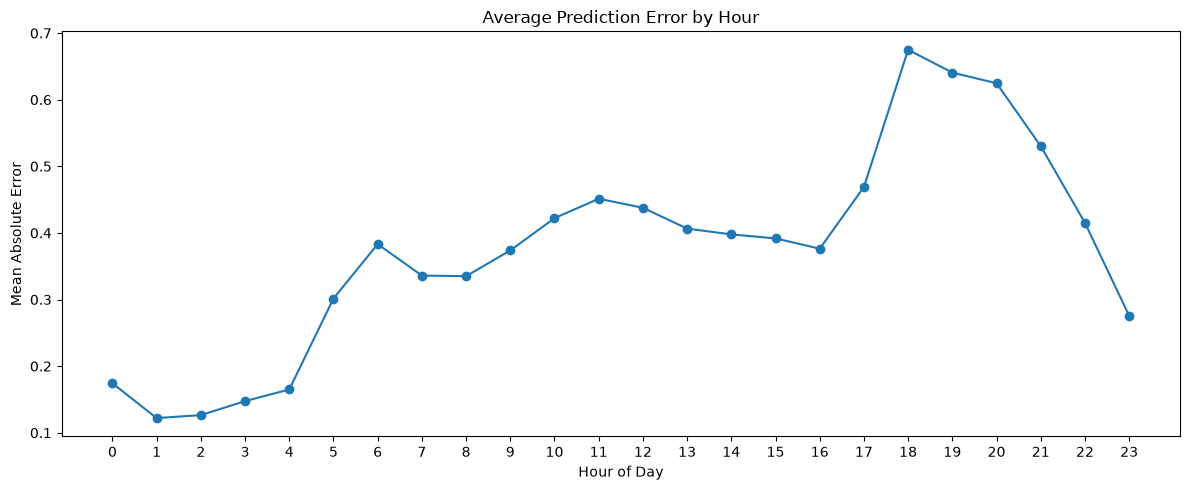

,MAE
Hour,
0,0.174236
1,0.122049
2,0.126519
3,0.147517
4,0.164991
5,0.301552
6,0.383128
7,0.335979
8,0.335063


In [12]:
hourly_error = (
    evaluation_df.groupby("Hour")["Absolute_Error"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_error.index,
    hourly_error.values,
    marker="o"
)

plt.title("Average Prediction Error by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

display(
    hourly_error.to_frame("MAE")
)


## 13. Error by Day of Week


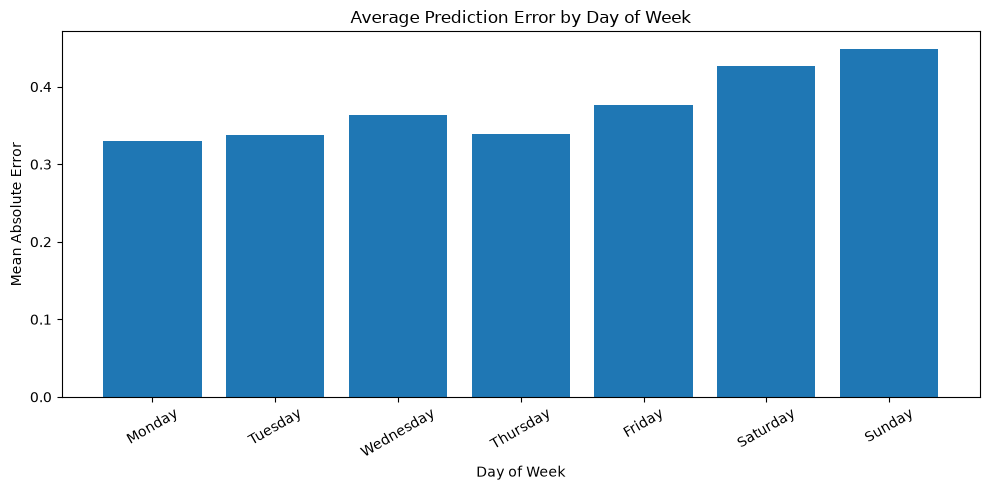

,MAE
DayName,
Monday,0.329350
Tuesday,0.337693
Wednesday,0.362974
Thursday,0.338398
Friday,0.376964
Saturday,0.426680
Sunday,0.448958


In [13]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_error = (
    evaluation_df.groupby("DayName")["Absolute_Error"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

plt.bar(
    daily_error.index,
    daily_error.values
)

plt.title("Average Prediction Error by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(
    daily_error.to_frame("MAE")
)


## 14. Error by Month


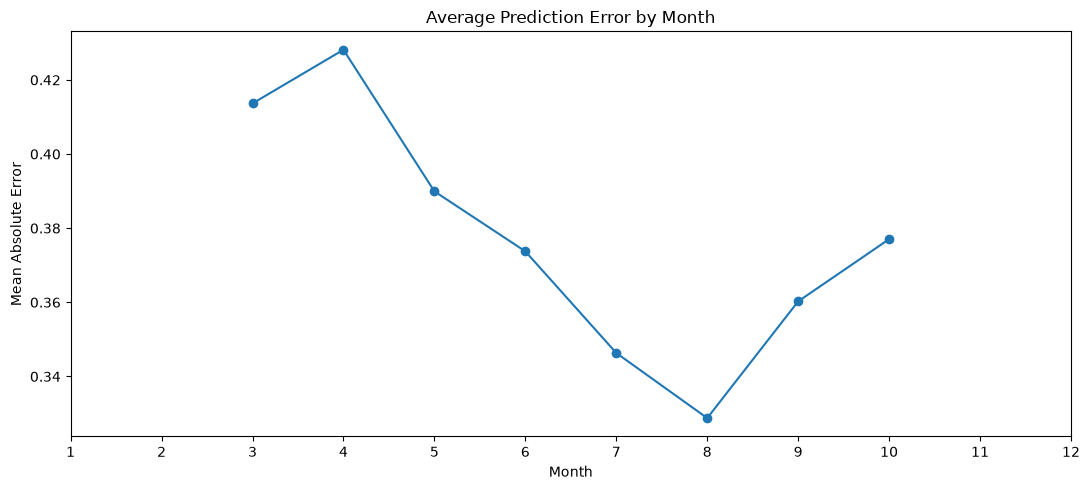

,MAE
Month,
3,0.413653
4,0.428135
5,0.389942
6,0.373751
7,0.346337
8,0.328771
9,0.360258
10,0.377039


In [14]:
monthly_error = (
    evaluation_df.groupby("Month")["Absolute_Error"]
    .mean()
)

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_error.index,
    monthly_error.values,
    marker="o"
)

plt.title("Average Prediction Error by Month")
plt.xlabel("Month")
plt.ylabel("Mean Absolute Error")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

display(
    monthly_error.to_frame("MAE")
)


## 15. Peak Consumption Analysis

Peak demand is particularly important in electricity management.

We define the top 10% of actual test observations as **high-consumption periods**.

Then we compare model performance during these periods with overall performance.


In [15]:
peak_threshold = evaluation_df["Actual"].quantile(0.90)

peak_df = evaluation_df[
    evaluation_df["Actual"] >= peak_threshold
].copy()

peak_mae = mean_absolute_error(
    peak_df["Actual"],
    peak_df["Predicted"]
)

peak_rmse = np.sqrt(
    mean_squared_error(
        peak_df["Actual"],
        peak_df["Predicted"]
    )
)

print("Peak threshold (90th percentile):", peak_threshold)
print("Number of peak observations:", len(peak_df))
print("Peak MAE :", peak_mae)
print("Peak RMSE:", peak_rmse)


Peak threshold (90th percentile): 1.8670266666666666
Number of peak observations: 489
Peak MAE : 0.8440108685225873
Peak RMSE: 1.0157190925253297


## 16. Top 10 Actual Consumption Periods

This table shows whether the model handled the largest consumption periods well.


In [16]:
top_10_actual = (
    evaluation_df[
        ["Actual", "Predicted", "Baseline", "Error", "Absolute_Error"]
    ]
    .sort_values("Actual", ascending=False)
    .head(10)
)

display(top_10_actual)


,Actual,Predicted,Baseline,Error,Absolute_Error
DateTime,,,,,
2009-04-12 20:00:00,5.133967,2.267862,2.653167,2.866105,2.866105
2009-04-12 19:00:00,5.098300,2.177724,1.767900,2.920576,2.920576
2009-09-12 21:00:00,4.450400,1.587739,2.326933,2.862661,2.862661
2009-03-28 17:00:00,4.375033,1.662773,1.201367,2.712260,2.712260
2009-04-11 18:00:00,4.304733,2.087404,1.605367,2.217330,2.217330
2009-09-12 20:00:00,4.300333,2.657912,3.061667,1.642422,1.642422
2009-05-03 19:00:00,4.265300,1.559000,1.363033,2.706300,2.706300
2009-04-11 19:00:00,4.145133,2.142200,2.010233,2.002934,2.002934
2009-03-17 19:00:00,3.874667,1.988815,0.410300,1.885851,1.885851


## 17. Largest Prediction Errors

These observations are useful for discussing limitations of the model in the project report.


In [17]:
top_10_errors = (
    evaluation_df[
        ["Actual", "Predicted", "Baseline", "Error", "Absolute_Error"]
    ]
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

display(top_10_errors)


,Actual,Predicted,Baseline,Error,Absolute_Error
DateTime,,,,,
2009-04-12 19:00:00,5.098300,2.177724,1.767900,2.920576,2.920576
2009-04-12 20:00:00,5.133967,2.267862,2.653167,2.866105,2.866105
2009-09-12 21:00:00,4.450400,1.587739,2.326933,2.862661,2.862661
2009-08-13 19:00:00,3.717533,0.855313,0.258528,2.862221,2.862221
2009-08-18 20:00:00,3.854100,1.113016,0.639733,2.741084,2.741084
2009-03-28 17:00:00,4.375033,1.662773,1.201367,2.712260,2.712260
2009-05-03 19:00:00,4.265300,1.559000,1.363033,2.706300,2.706300
2009-06-07 12:00:00,3.455467,1.026775,0.559867,2.428692,2.428692
2009-05-10 15:00:00,3.720567,1.308354,1.449967,2.412212,2.412212


## 18. Save Evaluation Predictions


In [18]:
prediction_output = "../data/processed/test_predictions.csv"

evaluation_df.to_csv(
    prediction_output,
    index_label="DateTime"
)

print("Prediction results saved to:", prediction_output)


Prediction results saved to: ../data/processed/test_predictions.csv


## 19. Final Evaluation Summary


In [19]:
print("===== FINAL EVALUATION SUMMARY =====")
print("Best model:", best_model_name)

print("\nOverall performance:")
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R²  :", best_r2)

print("\nBaseline:")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

print("\nImprovement over baseline:")
print("MAE improvement :", mae_improvement, "%")
print("RMSE improvement:", rmse_improvement, "%")

print("\nPeak-period performance:")
print("Peak MAE :", peak_mae)
print("Peak RMSE:", peak_rmse)

print("\nWorst hour by MAE:",
      hourly_error.idxmax(),
      "with MAE =", hourly_error.max())

print("Best hour by MAE:",
      hourly_error.idxmin(),
      "with MAE =", hourly_error.min())


===== FINAL EVALUATION SUMMARY =====
Best model: HistGradientBoosting

Overall performance:
MAE : 0.374329406315359
RMSE: 0.5184178276691596
R²  : 0.45543829902335753

Baseline:
MAE : 0.534100681393319
RMSE: 0.7952098232328327
R²  : -0.2812996599045363

Improvement over baseline:
MAE improvement : 29.914074376606585 %
RMSE improvement: 34.80741654302101 %

Peak-period performance:
Peak MAE : 0.8440108685225873
Peak RMSE: 1.0157190925253297

Worst hour by MAE: 18 with MAE = 0.6749574509077049
Best hour by MAE: 1 with MAE = 0.12204872302013725


## Conclusion

The forecasting model has now been evaluated from multiple perspectives.

### Completed

- Overall MAE, RMSE and R²
- Improvement over the previous-hour baseline
- Actual vs predicted visualization
- Residual analysis
- Hourly error analysis
- Weekday error analysis
- Monthly error analysis
- Peak-consumption evaluation
- Largest prediction errors
- Saved test predictions

### Next notebook

**09 - Forecasting / Prediction Demo**

We will create a reusable prediction workflow where a user can provide recent electricity-consumption information and obtain a next-hour forecast.

After that, we can move toward a **Streamlit dashboard** and final project documentation.
